In [1]:
import mne
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("MNE Version:", mne.__version__)

MNE Version: 1.12.1


In [2]:
from pathlib import Path

DATA_DIR = Path("../data/eegmmidb/files")

subjects = sorted([d.name for d in DATA_DIR.iterdir() if d.is_dir()])

print("Total Subjects Found:", len(subjects))
print(subjects[:5])
print(subjects[-5:])

Total Subjects Found: 109
['S001', 'S002', 'S003', 'S004', 'S005']
['S105', 'S106', 'S107', 'S108', 'S109']


In [3]:
discarded = {
    "S043",
    "S088",
    "S089",
    "S092",
    "S100",
    "S104"
}

valid_subjects = [s for s in subjects if s not in discarded]

print("Valid Subjects:", len(valid_subjects))

Valid Subjects: 103


In [4]:
from pathlib import Path

subject_dir = DATA_DIR / "S001"

edf_files = sorted(subject_dir.glob("*.edf"))

for f in edf_files:
    print(f.name)

S001R01.edf
S001R02.edf
S001R03.edf
S001R04.edf
S001R05.edf
S001R06.edf
S001R07.edf
S001R08.edf
S001R09.edf
S001R10.edf
S001R11.edf
S001R12.edf
S001R13.edf
S001R14.edf


In [5]:
for run in ["R04", "R08", "R12"]:
    path = subject_dir / f"S001{run}.edf"
    print(path.exists(), path.name)

True S001R04.edf
True S001R08.edf
True S001R12.edf


In [6]:
import mne
from pathlib import Path

edf_path = Path("../data/eegmmidb/files/S001/S001R04.edf")

raw = mne.io.read_raw_edf(edf_path, preload=True)

print(raw)

Extracting EDF parameters from ..\data\eegmmidb\files\S001\S001R04.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
<RawEDF | S001R04.edf, 64 x 20000 (125.0 s), ~9.8 MiB, data loaded>


In [7]:
print("Sampling Rate:", raw.info["sfreq"])
print("Channels:", len(raw.ch_names))
print("Samples:", raw.n_times)

Sampling Rate: 160.0
Channels: 64
Samples: 20000


In [8]:
print(raw.ch_names)

['Fc5.', 'Fc3.', 'Fc1.', 'Fcz.', 'Fc2.', 'Fc4.', 'Fc6.', 'C5..', 'C3..', 'C1..', 'Cz..', 'C2..', 'C4..', 'C6..', 'Cp5.', 'Cp3.', 'Cp1.', 'Cpz.', 'Cp2.', 'Cp4.', 'Cp6.', 'Fp1.', 'Fpz.', 'Fp2.', 'Af7.', 'Af3.', 'Afz.', 'Af4.', 'Af8.', 'F7..', 'F5..', 'F3..', 'F1..', 'Fz..', 'F2..', 'F4..', 'F6..', 'F8..', 'Ft7.', 'Ft8.', 'T7..', 'T8..', 'T9..', 'T10.', 'Tp7.', 'Tp8.', 'P7..', 'P5..', 'P3..', 'P1..', 'Pz..', 'P2..', 'P4..', 'P6..', 'P8..', 'Po7.', 'Po3.', 'Poz.', 'Po4.', 'Po8.', 'O1..', 'Oz..', 'O2..', 'Iz..']


In [9]:
events, event_id = mne.events_from_annotations(raw)

print("Event IDs:")
print(event_id)

print("\nNumber of Events:")
print(len(events))

Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
Event IDs:
{np.str_('T0'): 1, np.str_('T1'): 2, np.str_('T2'): 3}

Number of Events:
30


In [10]:
data = raw.get_data()

print(data.shape)

(64, 20000)


Using matplotlib as 2D backend.


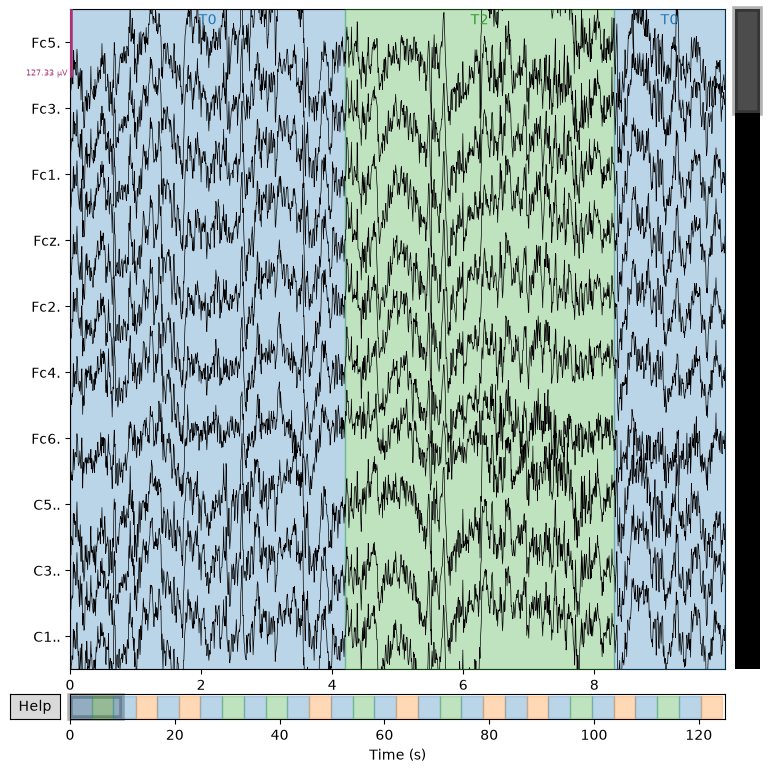

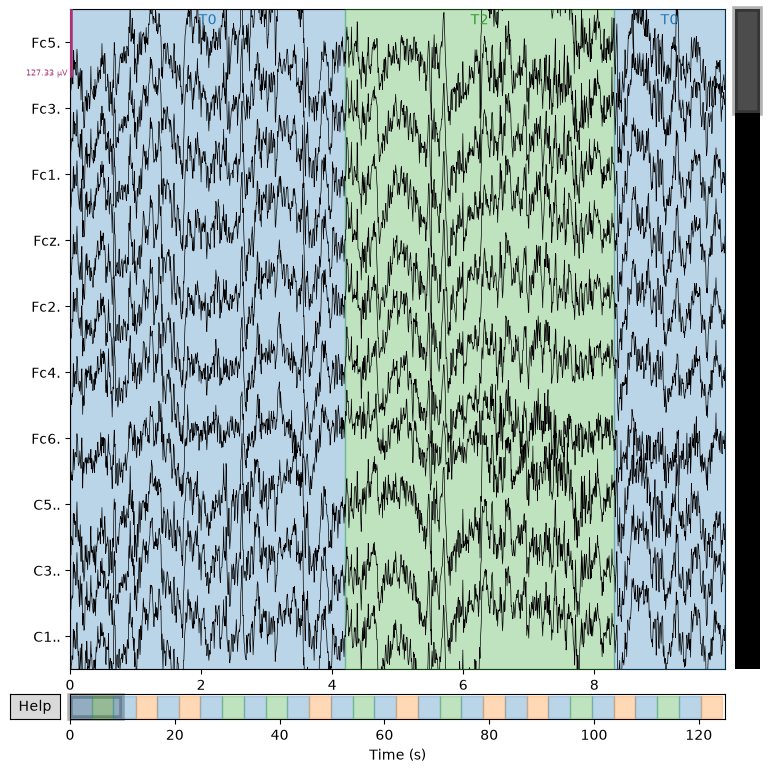

In [11]:
raw.plot(duration=10, n_channels=10, scalings='auto')

In [12]:
for i, ch in enumerate(raw.ch_names):
    print(i, ch)

0 Fc5.
1 Fc3.
2 Fc1.
3 Fcz.
4 Fc2.
5 Fc4.
6 Fc6.
7 C5..
8 C3..
9 C1..
10 Cz..
11 C2..
12 C4..
13 C6..
14 Cp5.
15 Cp3.
16 Cp1.
17 Cpz.
18 Cp2.
19 Cp4.
20 Cp6.
21 Fp1.
22 Fpz.
23 Fp2.
24 Af7.
25 Af3.
26 Afz.
27 Af4.
28 Af8.
29 F7..
30 F5..
31 F3..
32 F1..
33 Fz..
34 F2..
35 F4..
36 F6..
37 F8..
38 Ft7.
39 Ft8.
40 T7..
41 T8..
42 T9..
43 T10.
44 Tp7.
45 Tp8.
46 P7..
47 P5..
48 P3..
49 P1..
50 Pz..
51 P2..
52 P4..
53 P6..
54 P8..
55 Po7.
56 Po3.
57 Poz.
58 Po4.
59 Po8.
60 O1..
61 Oz..
62 O2..
63 Iz..


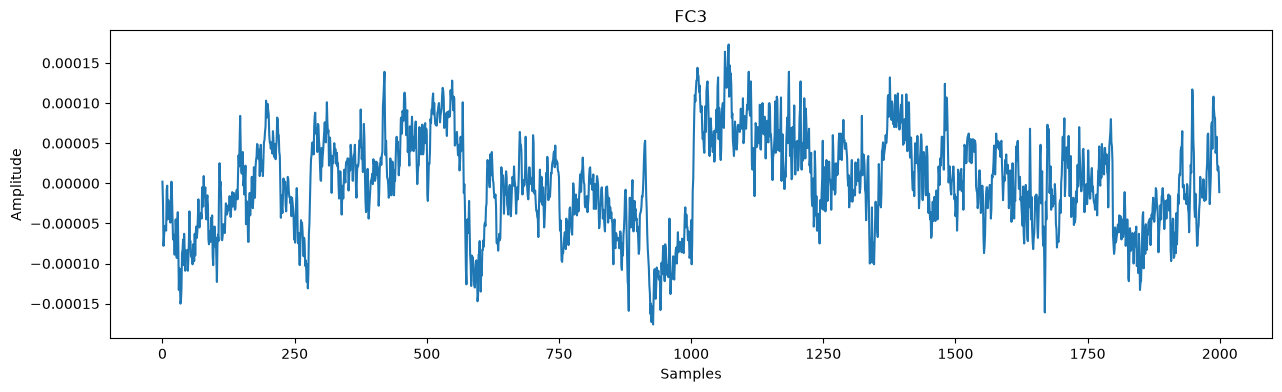

In [13]:
data = raw.get_data()

plt.figure(figsize=(15,4))
plt.plot(data[1, :2000])  # replace 1 with actual FC3 index
plt.title("FC3")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.show()

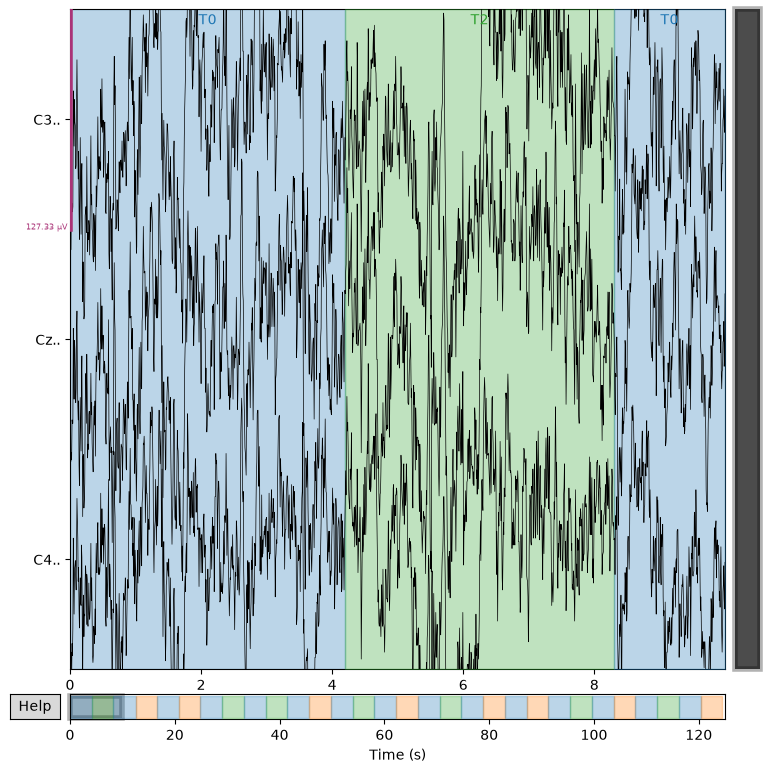

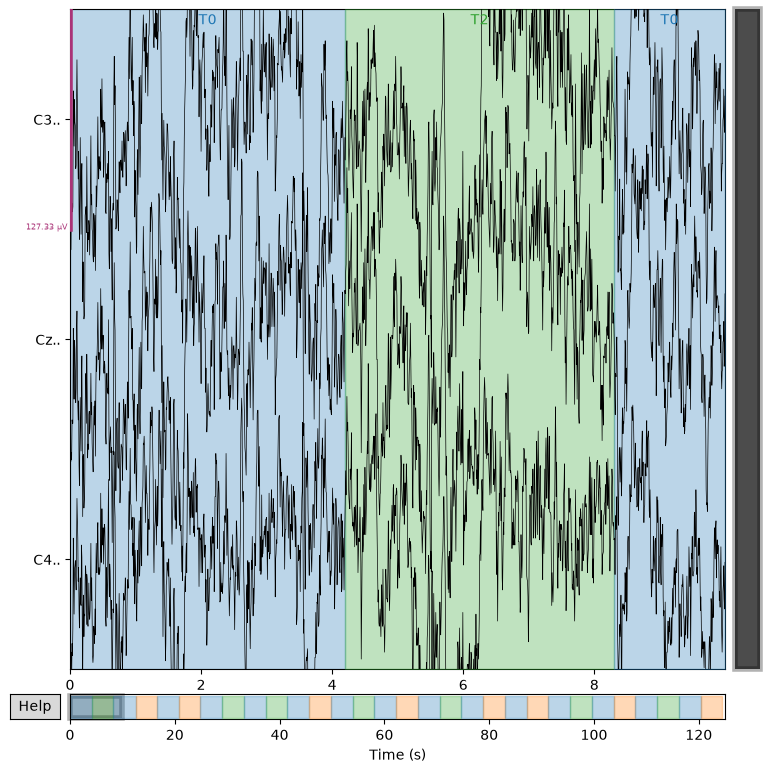

In [14]:
raw.plot(
    picks=['C3..','Cz..','C4..'],
    duration=10,
    scalings='auto'
)

Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]


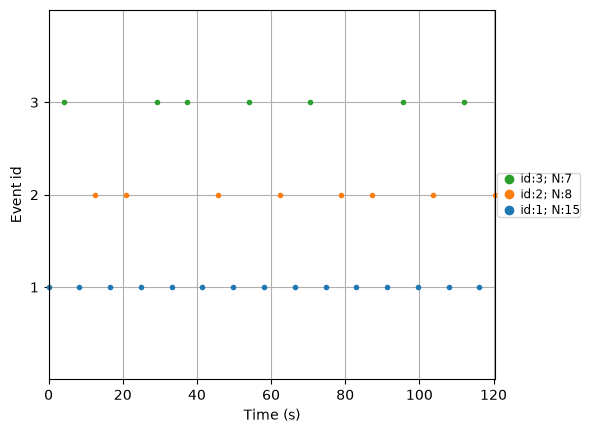

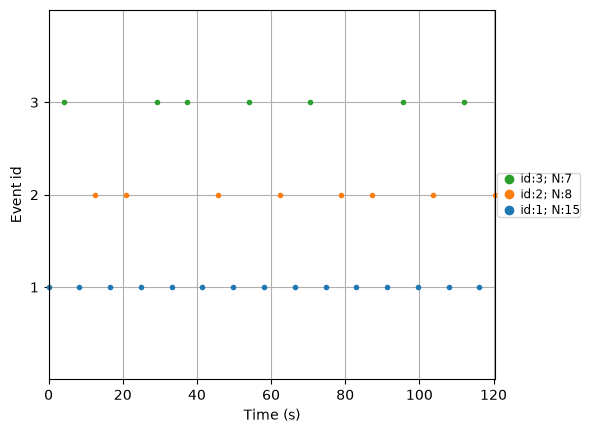

In [15]:
events, event_id = mne.events_from_annotations(raw)

mne.viz.plot_events(
    events,
    sfreq=raw.info['sfreq']
)

Effective window size : 12.800 (s)
Plotting power spectral density (dB=True).


C:\Users\gurle\AppData\Local\Temp\ipykernel_17496\4108630121.py:1: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  raw.compute_psd().plot()
c:\Users\gurle\Downloads\EEG_LSTM_Replication\.venv\Lib\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


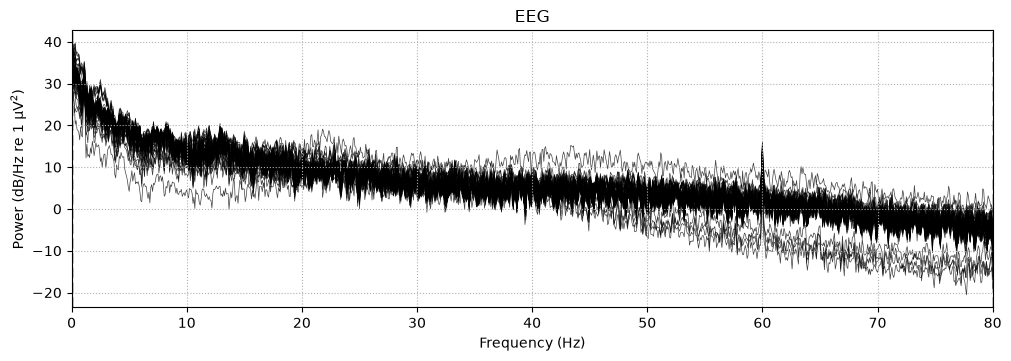

In [16]:
raw.compute_psd().plot()

Effective window size : 12.800 (s)
Plotting power spectral density (dB=True).


C:\Users\gurle\AppData\Local\Temp\ipykernel_17496\290510763.py:3: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  ).plot()
c:\Users\gurle\Downloads\EEG_LSTM_Replication\.venv\Lib\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


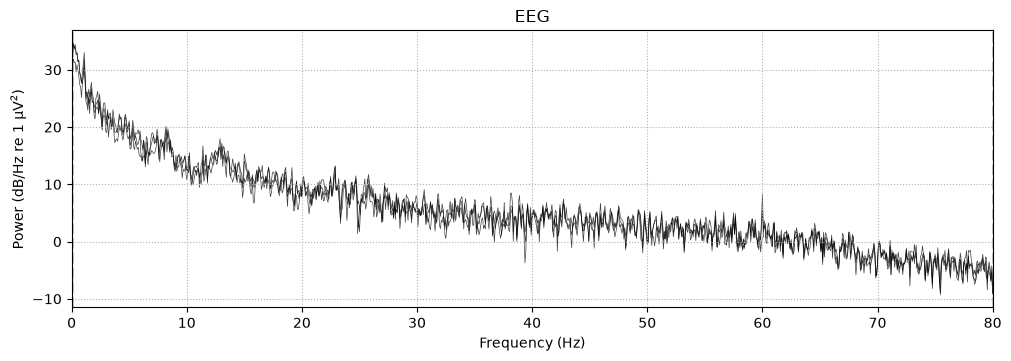

In [17]:
raw.compute_psd(
    picks=['C3..','Cz..','C4..']
).plot()

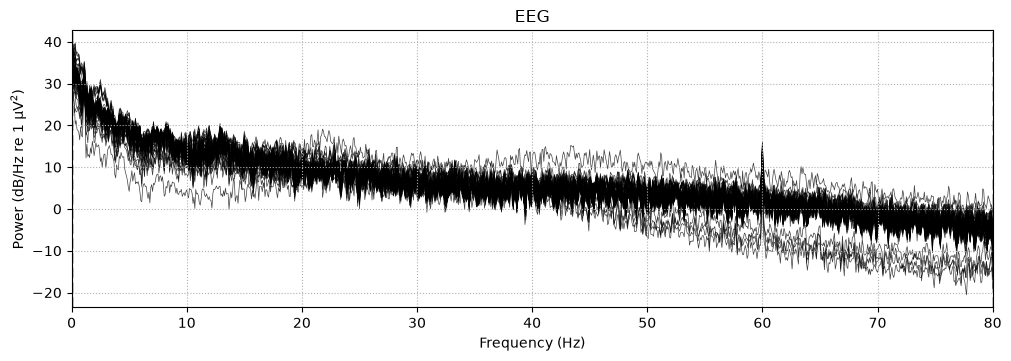

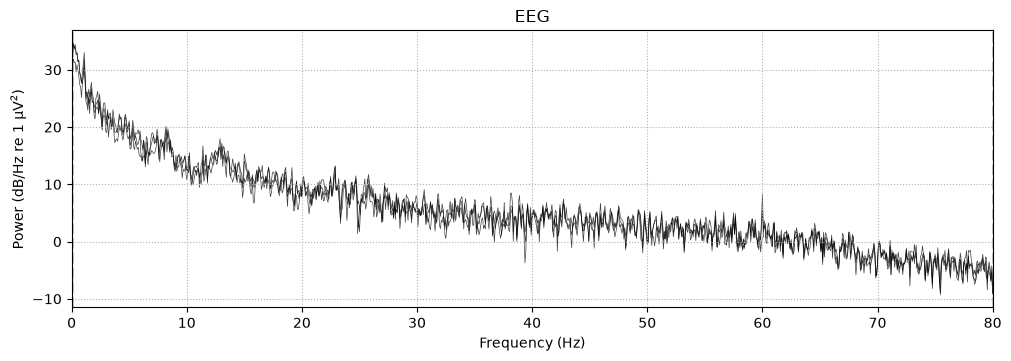

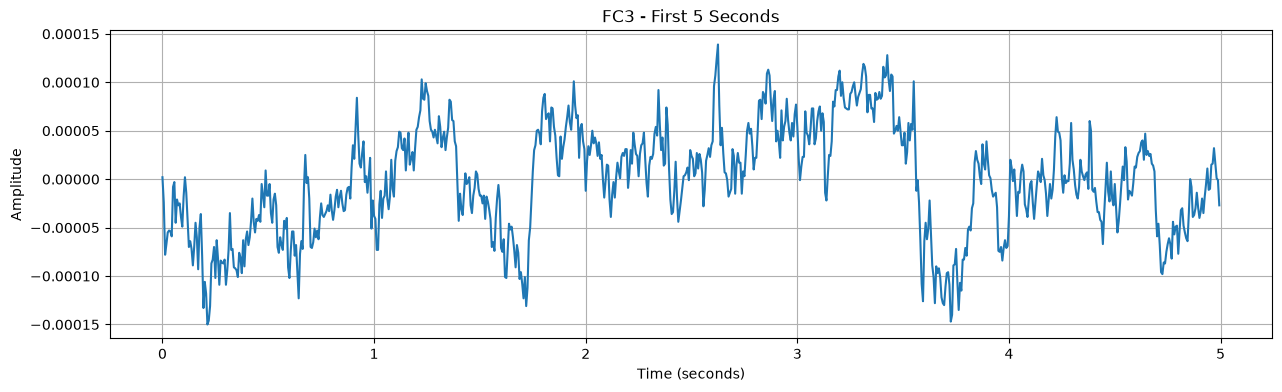

In [18]:
fs = int(raw.info['sfreq'])

fc3_idx = raw.ch_names.index('Fc3.')

signal = raw.get_data()[fc3_idx]

time = np.arange(len(signal))/fs

plt.figure(figsize=(15,4))
plt.plot(time[:5*fs], signal[:5*fs])
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.title("FC3 - First 5 Seconds")
plt.grid()
plt.show()

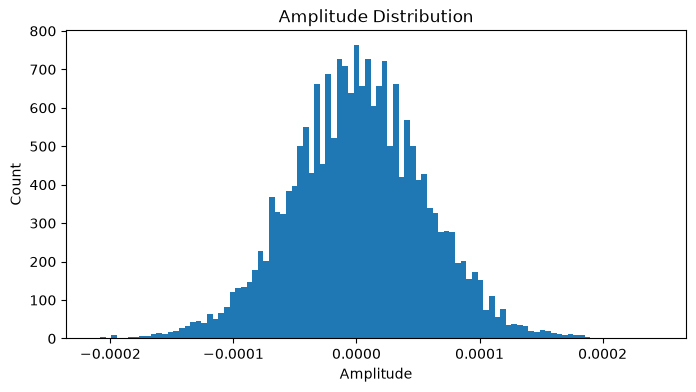

In [19]:
signal = raw.get_data()[fc3_idx]

plt.figure(figsize=(8,4))
plt.hist(signal, bins=100)
plt.title("Amplitude Distribution")
plt.xlabel("Amplitude")
plt.ylabel("Count")
plt.show()